In [14]:
import sys
from pathlib import Path
ROOT = Path.cwd().parents[0]   # repo root
sys.path.insert(0, str(ROOT))
##
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

from src.features.feature_engineering import add_time_and_lag_features
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.base import clone
from sklearn.linear_model import Ridge

import webbrowser
import time

from src.data.build_clean_df import load_stations_data
from src.optimization.clustering import cluster_candidate_station
from src.optimization.bike_rebalancing import bike_rebalancing
from src.optimization.visualize_opt  import visualize_cluster, print_truck_routes_report, visualize_truck_routes

## Set hour to optimize

In [2]:
hour_to_optimize = '2017-11-14 08:00:00'

open_html_in_web_browser = False

### Loading processed data

In [3]:
# if this cell is not working please run the models.ipynb notebook to generate the processed data csv
demand = pd.read_csv("../data/processed/divvy_hourly_demand_weather.csv")
demand["hour"] = pd.to_datetime(demand["hour"])
demand = add_time_and_lag_features(demand=demand,lags=(1, 24, 168),drop_na_lags=True)
demand.head()

,station_id,hour,departures,arrivals,net_demand,temp,tmin,tmax,rhum,prcp,...,dow_sin,dow_cos,month_sin,month_cos,dep_lag_1,arr_lag_1,dep_lag_24,arr_lag_24,dep_lag_168,arr_lag_168
168,2,2017-01-08 00:00:00,0,0,0,-11.5,-15.8,-6.8,50,0.0,...,-0.781831,0.62349,0.5,0.866025,0.0,1.0,0.0,0.0,0.0,0.0
169,2,2017-01-08 01:00:00,0,0,0,-11.5,-15.8,-6.8,50,0.0,...,-0.781831,0.62349,0.5,0.866025,0.0,0.0,0.0,0.0,0.0,0.0
170,2,2017-01-08 02:00:00,0,0,0,-11.5,-15.8,-6.8,50,0.0,...,-0.781831,0.62349,0.5,0.866025,0.0,0.0,0.0,0.0,0.0,0.0
171,2,2017-01-08 03:00:00,0,0,0,-11.5,-15.8,-6.8,50,0.0,...,-0.781831,0.62349,0.5,0.866025,0.0,0.0,0.0,0.0,0.0,0.0
172,2,2017-01-08 04:00:00,0,0,0,-11.5,-15.8,-6.8,50,0.0,...,-0.781831,0.62349,0.5,0.866025,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
stations = load_stations_data()

### Demand prediction

In [5]:
y_dep = demand["departures"]
y_arr = demand["arrivals"]

feature_cols = [
    "hour_sin","hour_cos",
    "dow_sin","dow_cos",
    "month_sin","month_cos",
    "is_weekend",
    "temp","tmin","tmax","rhum","prcp","snwd","wspd","pres",
    "dep_lag_1","dep_lag_24", 'dep_lag_168',
    "arr_lag_1","arr_lag_24", "arr_lag_168"
]

X = demand[feature_cols]

split_time = demand["hour"].quantile(0.8)

train = demand["hour"] <= split_time
test  = demand["hour"] > split_time

X_train = X[train]
X_test  = X[test]

y_dep_train = y_dep[train]
y_dep_test  = y_dep[test]

y_arr_train = y_arr[train]
y_arr_test  = y_arr[test]

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

In [6]:
model = Ridge(alpha=1.0, random_state=42)

print(f"Training Ridge...")

# departures
mdl_dep = clone(model)
mdl_dep.fit(X_train, y_dep_train)
pred_dep = mdl_dep.predict(X_test)

# arrivals
mdl_arr = clone(model)
mdl_arr.fit(X_train, y_arr_train)
pred_arr = mdl_arr.predict(X_test)

pred_dep = np.clip(pred_dep, 0, None)
pred_arr = np.clip(pred_arr, 0, None)

pred_net = pred_dep - pred_arr
true_net = y_dep_test - y_arr_test

results = pd.DataFrame([{
    "model": "Ridge",
    "dep_MAE": mean_absolute_error(y_dep_test, pred_dep),
    "dep_RMSE": rmse(y_dep_test, pred_dep),
    "arr_MAE": mean_absolute_error(y_arr_test, pred_arr),
    "arr_RMSE": rmse(y_arr_test, pred_arr),
    "net_MAE": mean_absolute_error(true_net, pred_net),
    "net_RMSE": rmse(true_net, pred_net),
}])
results.head()

Training Ridge...


,model,dep_MAE,dep_RMSE,arr_MAE,arr_RMSE,net_MAE,net_RMSE
0,Ridge,0.374209,0.945263,0.373062,0.969262,0.456264,1.099768


In [7]:
# build pred_df 
pred_df = demand[test][['station_id','hour','departures','arrivals','net_demand']].rename(columns={
    "net_demand" : "true_net_demand",
    "departures" : "true_departures",
    "arrivals" : "true_arrivals"
})
pred_df['pred_arrivals'] = pred_arr.round()
pred_df['pred_departures'] = pred_dep.round()
pred_df['pred_net_demand'] = pred_net.round()

pred_df = pred_df.merge(stations, left_on='station_id', right_on='id', how='left')
pred_df.drop(columns=['id'], inplace=True)
pred_df = pred_df[['hour','station_id','pred_departures', 'true_departures','pred_arrivals', 'true_arrivals',
       'pred_net_demand','true_net_demand','dpcapacity', 'latitude', 'longitude','name']]

# hourly_net_demand = pred_df.groupby(pred_df['hour'])[['pred_net_demand','true_net_demand']].agg(lambda x: x.abs().sum()).reset_index().sort_values(['pred_net_demand'], ascending=False)
# hourly_net_demand[hourly_net_demand['hour']==hour_to_optimize]



## Filtering candidate and clustering

In [8]:
# function to apply first layer (candidate selection) + 2nd layer (clusterization)
candidate_stations = cluster_candidate_station(pred_df=pred_df, stations=stations, hour_to_optimize=hour_to_optimize,acceptable_margin=0.2, stations_per_cluster=25, random_init_state=True)

In [9]:
# visualize cluster for this hour

visualize_cluster(candidate_stations=candidate_stations, hour_to_optimize=hour_to_optimize)

if open_html_in_web_browser==True :
    webbrowser.open(f"..\plots\clusters_map\station_clusters_{hour_to_optimize[:-6]}.html")

station_clusters_2017-11-14 08.html saved in plots/clusters_map


## bike rebalancing

### testing with only one cluster

In [10]:
cluster_0 = bike_rebalancing(stations=stations,
                     pred_df=pred_df,
                     hour_to_optimize=hour_to_optimize,
                     candidate_stations=candidate_stations,
                     cluster_nb=0,
                     gamma=10,
                     nb_trucks=1,
                     random_init_state=True)
    
cluster_0['objective']

Set parameter Username
Set parameter LicenseID to value 2718992
Academic license - for non-commercial use only - expires 2026-10-07
Solver status: Optimal


19.741249532217548

In [11]:
# print truck report for this cluster
solution = {}
solution[0] = cluster_0
print_truck_routes_report(solutions_dict=solution)


===== TRUCK ROUTE REPORT (ALL CLUSTERS) =====


Truck 0 (cluster 0) :
  Goes from 0 -> 214 | Distance: 0.33 km | Drop: 0, Pick: 8, Truck load before arrival: 0
  Goes from 214 -> 215 | Distance: 1.11 km | Drop: 3, Pick: 0, Truck load before arrival: 8
  Goes from 215 -> 146 | Distance: 1.14 km | Drop: 1, Pick: 0, Truck load before arrival: 5
  Goes from 146 -> 134 | Distance: 1.02 km | Drop: 4, Pick: 0, Truck load before arrival: 5
  Goes from 134 -> 88 | Distance: 0.92 km | Drop: 0, Pick: 12, Truck load before arrival: 1
  Goes from 88 -> 54 | Distance: 1.39 km | Drop: 3, Pick: 0, Truck load before arrival: 13
  Goes from 54 -> 111 | Distance: 1.31 km | Drop: 0, Pick: 15, Truck load before arrival: 10
  Goes from 111 -> 291 | Distance: 1.37 km | Drop: 3, Pick: 0, Truck load before arrival: 25
  Goes from 291 -> 268 | Distance: 0.87 km | Drop: 1, Pick: 0, Truck load before arrival: 23
  Goes from 268 -> 143 | Distance: 1.53 km | Drop: 3, Pick: 0, Truck load before arrival: 22
  Goes f

### testing with all cluster

In [12]:
# loop to optimize within each cluster and collect solutions

solutions_dict = {}
nb_clusters = candidate_stations['cluster'].max() + 1
for cluster in range(nb_clusters):
    print(f'Optimizing cluster {cluster}...')
    start_time = time.time()
    solutions_dict[cluster] = bike_rebalancing(stations=stations,
                     pred_df=pred_df,
                     hour_to_optimize=hour_to_optimize,
                     candidate_stations=candidate_stations,
                     cluster_nb=cluster,
                     gamma=10,
                     nb_trucks=1,
                     random_init_state=True)
    end_time = time.time()
    duration = round(end_time - start_time)
    print(f'Solution found for cluster {cluster} in {duration} sec')


Optimizing cluster 0...
Solver status: Optimal
Solution found for cluster 0 in 4 sec
Optimizing cluster 1...
Solver status: Time limit reached
Solution found for cluster 1 in 60 sec
Optimizing cluster 2...
Solver status: Time limit reached
Solution found for cluster 2 in 61 sec
Optimizing cluster 3...
Solver status: Optimal
Solution found for cluster 3 in 1 sec
Optimizing cluster 4...
Solver status: Optimal
Solution found for cluster 4 in 2 sec
Optimizing cluster 5...
Solver status: Optimal
Solution found for cluster 5 in 7 sec
Optimizing cluster 6...
Solver status: Optimal
Solution found for cluster 6 in 3 sec
Optimizing cluster 7...
Solver status: Optimal
Solution found for cluster 7 in 11 sec


In [13]:
print_truck_routes_report(solutions_dict)


===== TRUCK ROUTE REPORT (ALL CLUSTERS) =====


Truck 0 (cluster 0) :
  Goes from 0 -> 214 | Distance: 0.33 km | Drop: 0, Pick: 8, Truck load before arrival: 0
  Goes from 214 -> 215 | Distance: 1.11 km | Drop: 3, Pick: 0, Truck load before arrival: 8
  Goes from 215 -> 146 | Distance: 1.14 km | Drop: 1, Pick: 0, Truck load before arrival: 5
  Goes from 146 -> 134 | Distance: 1.02 km | Drop: 4, Pick: 0, Truck load before arrival: 5
  Goes from 134 -> 88 | Distance: 0.92 km | Drop: 0, Pick: 12, Truck load before arrival: 1
  Goes from 88 -> 54 | Distance: 1.39 km | Drop: 3, Pick: 0, Truck load before arrival: 13
  Goes from 54 -> 111 | Distance: 1.31 km | Drop: 0, Pick: 15, Truck load before arrival: 10
  Goes from 111 -> 291 | Distance: 1.37 km | Drop: 3, Pick: 0, Truck load before arrival: 25
  Goes from 291 -> 268 | Distance: 0.87 km | Drop: 1, Pick: 0, Truck load before arrival: 23
  Goes from 268 -> 143 | Distance: 1.53 km | Drop: 3, Pick: 0, Truck load before arrival: 22
  Goes f

In [14]:
# visualizing truck routes
visualize_truck_routes(stations=stations,solutions_dict=solutions_dict,hour_to_optimize=hour_to_optimize)
if open_html_in_web_browser==True :
    webbrowser.open(f"..\plots\\truck_routes_map\\truck_routes_map_{hour_to_optimize[:-6]}.html")

truck_routes_map_2017-11-14 08.html saved in plots/truck_routes_map


# Model maths

We want to optimize the rebalancing of a bike-sharing system using multiple trucks. We will translate this problem into a MILP problem using a set of Equations.

## Notations & Parameters

The bike-sharing network is made of tens of stations. We denote : 
- $i$ the **i-th station**, $I$ being the set of stations. 
- $j$ the **j-th station**, $I$ being the set of stations. 

(Nb : Note that we need two distinct index so that we can distinguish an arrival and departure station).

For each station, we know : 

- $S_i$ the **initial state of the station**, as the number of bikes currently available at the station.
- $C_i$ the **total number of docks at the station**. 
- $\delta_i$ the **estimated net demand** for the next hour at the station (obtained through ML prediction)

For each pair of station, we know : 

- $D_{i,j}$ the **distance between the i-th and j-th station in km**

A set of **parameters must be chosen** by the user : 

- $\gamma$ is a parameter to **control how much not meeting demand will be penalized**
- $k$ is the **number of trucks** available ($K$ being the total number of trucks)
- $\forall k \in K, T_{max,k}$ is the **maximum capacity of the truck $k$**.
- $\forall i \in I, \alpha_i \in [0,1]$ is the **minimum acceptable service level at station $i$**
expressed as a proportion of the maximum capacity of the station $C_i$. (i.e. minimal percentage
of available bikes and free docks that should remain at the station)

#### Decision Variables

To optimize the rebalancing of the network, both in terms of **service level** and **costs** we have
to make some decisions, represented in our model by these decision variables : 

- $\forall i, k \in I \times K, X_{i,k}$ is the **number of bike to drop off** at station $i$ by truck $k$
- $\forall i, k \in I \times K, Y_{i,k}$ is the **number of bike to pick up** at station $i$ by truck $k$
- $\forall i,j, k \in I \times I \times K , W_{i,j,k}$ is a **binary variable indicating if the truck $k$ is moving from station $i$ to station $j$** (1 if it does, 0 if not)

## Objective function

Our goal is to minimize the costs incurred by the trucks, thus we want to minimize the total distance 
travelled by our trucks defined as : 

$$\sum_{i,j,k}{W_{i,j,k} \times D_{i,j}}$$

But we want to minimize our costs, while maintaining a good service level, we thus define : 

- $\forall i, P_{i}$ is a **penalty for not meeting demand of bikes at station $i$**. The penalty
is equal to the difference between the number of bikes actually available at the station and the number
of bikes required to match the service level requirement $\alpha_i$

- $\forall i, Q_{i}$ is a **penalty for not meeting demand of free docks at station $i$**. The penalty
is equal to the difference between the number of free docks actually available at the station and the number of docks required to match the service level requirement $\alpha_i$

Thus, our **objective function** becomes : 

$$\sum_{i,j,k}{W_{i,j,k} \times D_{i,j}} \quad + \quad  \gamma \times \sum_{i}{P_i + Q_i} $$

## Constraints

### Non-negativity constraints 

The **number of bikes dropped of or picked up at each station can only be positive**, we have : 

$$ \forall i,k \in I \times K, \quad X_{i,k} \geq 0$$
$$ \forall i,k \in I \times K, \quad Y_{i,k} \geq 0$$

### Stable system constraint

We want our rebalancing to be net zero in terms of bikes. We want **the total number of bikes dropped off to be equal to the total number of bikes picked up** : 

$$\sum_{i,k}{X_{i,k}} = \sum_{i,k}{Y_{i,k}}$$

### Station capacity constraint

The number of bikes in the stations after we perform our rebalancing strategy should not exceed maximum capacity of the station : 

$$\forall i \in I, \quad S_i + \sum_{k}{X_{i,k}} - \sum_{k}{Y_{i,k}} \leq C_i$$

$$\forall i \in I, \quad S_i + \sum_{k}{X_{i,k}} - \sum_{k}{Y_{i,k}} \geq 0$$




### Truck routing logic constraints

First, we want to link the actions (dropping off or picking up bikes) we perform at each station with the path the truck is taking. 
In other words, **if we perform an action at a station, the truck must go to the station**, we have : 

$$\forall i, k \in I \times K,\quad \sum_{j}{W_{i,j,k}} \leq X_{i,k} + Y_{i,k}$$

(NB : this ensures that if a truck does nothing at the station, the truck does not go to the station)

$$\forall i, k \in I \times K,\quad X_{i,k} + Y_{i,k} \leq M \times \sum_{j}{W_{i,j,k}}$$

where $M$ is a placeholder for a massive number. 

(NB : this ensures that if a truck performs an action at the station, it goes to the station)

Next, to avoid any kind of teleportations by the trucks, we want to ensure that **any time a trucks enters a station, it should eventually leave it**, we have : 

$$\forall k \in K, \quad \sum_{j}{W_{i,j,k}} \quad = \quad \sum_{j}{W_{j,i,k}}$$

$$\forall i,k  \in I \times K, \quad W_{i,i,k} = 0$$

(NB : the last equation avoid the model to trick itself)

Then, we do **not want a same truck to go multiple times in the same station**, we have : 

$$\forall i,k \in I \times K, \quad \sum_{j}{W_{i,j,k}} \leq 1$$

The trucks used for the rebalancing system are stored in a warehouse, this **warehouse represented by the index 0 must be the starting point of each truck trip**, we have : 

$$\forall k \in K, \quad \sum_{j}{W_{0,j,k}} = 1$$

### Truck bike-storing logic constraints 

We denote : 

- $\forall i,k \in I \times K, T_{i,k}$ is **the number of bikes in truck $k$ before entering station $i$**

First, it should be positive, we have : 

$$\forall i,k  \in I \times K, \quad T_{i,k} \geq 0$$

Then, **the number of bikes in the truck when leaving the warehouse should be equal to 0**, we have : 

$$\forall i,k  \in I \times K, \quad T_{i,k} \leq M \times (1 - W_{0,i,k})$$

Then, **the number of bikes in the truck before returning to the warehouse shoudl be equal to 0**, we have : 

$$\forall k \in K, \quad T_{0,k} = 0$$

Next, **the number of bikes in the truck should not exceed the maximum capacity of the truck**, we have : 

$$\forall i,k \in I \times K, \quad T_{i,k} \leq T_{max,k}$$

And, **the number of bikes dropped off at station $i$ can not exceed the number of bikes in the truck before entering station $i$**, we have : 

$$\forall i,k \in I \times K, \quad X_{i,k} \leq T_{i,k}$$

Similarly, **the number of bikes picked up at station $i$ can not exceed the remaining space in the truck** , we have : 

$$\forall i,k \in I \times K, \quad Y_{i,k} \leq T_{max,k} - T_{i,k}$$

Finally, we need to **link the number of bikes in the truck before entering station $j$ to the action that were performed by the truck in station $i$** if the truck actually make the trip from $i$ to $j$ : 

$$ \forall i,j,k \in I \times I \times K, \quad T_{j,k} \leq T_{i,k} + Y_{i,k} - X_{i,k} + M \times (1-W_{i,j,k})$$
$$ \forall i,j,k \in I \times I \times K, \quad T_{j,k} \geq T_{i,k} + Y_{i,k} - X_{i,k} - M \times (1-W_{i,j,k})$$

(NB : these two equations allow that if the trip is not made between $i$ and $j$ then there is no constraint. But if the trip is done then we must have $T_{j,k} = T_{i,k} + Y_{i,k} - X_{i,k}$)


### Service-level constraints

First, we want to ensure that **we penalize our model with $P_i$ if the number of bikes at station $i$ is not enough to match the required
service-level $\alpha_i$**, thus we have : 

$$\forall i \in I, \quad \alpha_i \times C_i - [S_i - \delta_i + \sum_{k}{X_{i,k}} - \sum_{k}{Y_{i,k}}] \leq P_i$$

$$P_i \leq M \times y_i$$

$$\forall i \in I, \quad \alpha_i \times C_i - [S_i - \delta_i + \sum_{k}{X_{i,k}} - \sum_{k}{Y_{i,k}}] \geq P_i - M \times (1-y_i)$$

where $y_i$ is a binary variable. 

**Explanation**

For a given station $i$, the service level we want to meet is equal to $\alpha_i \times C_i$. The number of bikes in the station $i$ after we perform our rebalancing strategy and the demand for the next hour happen is $S_i + \delta_i + \sum_{k}{X_{i,k}} - \sum_{k}{Y_{i,k}}$. Thus, matching the required service level means that the left part of the third equation is negative. As $P_i$ is positive, the only way for the equation to hold is to set $y_i=0$. Looking at the second equation, this ensures no penalization is applied.

On the contrary, not matching the required service level means the left part of the first equation is positive, which implies that $P_i$ is positive. Then, looking at the second equation, this forces $y_i = 1$ and we thus have $ P_i = C_i - [S_i + \delta_i + \sum_{k}{X_{i,k}} - \sum_{k}{Y_{i,k}}]$.

Finally, we also want to ensure that **we penalize our model with $Q_i$ if the number of free docks at station $i$ is not enough to match the required service-level $\alpha_i$**, thus we have :


$$\forall i \in I, \quad (\alpha_i - 1) \times C_i + [S_i - \delta_i + \sum_{k}{X_{i,k}} - \sum_{k}{Y_{i,k}}] \leq Q_i$$

$$Q_i \leq M \times z_i$$

$$\forall i \in I, \quad (\alpha_i-1) \times C_i + [S_i - \delta_i + \sum_{k}{X_{i,k}} - \sum_{k}{Y_{i,k}}] \geq Q_i - M \times (1-z_i)$$

where $z_i$ is a binary variable. 

### Miller-Tucker-Zemlin subtour elimination constraint

We need to make sure no subtour are created. We denote : 

- $\forall i, k \in I \times K, U_{i,k}$ is the **visit order of station $i$ in truck $k$'s route**

Then we have : 

$$\forall i, k \in I \times K, \quad 1 \leq U_{i,k} \leq |I|$$
$$\forall k \in K, \quad U_{0,k} = 0$$

And : 

$$\forall i,j,k \in I \times I \times K, i \neq j, \quad U_{i,k} - U_{j,k} + |I| \times W_{i,j,k} \leq |I|-1$$





# Testing different gamma

In [25]:
# loop to optimize for each gamma within each cluster and collect solutions
hour_to_optimize ='2017-11-14 08:00:00'
solutions_dict = {}
for gamma in np.arange(.1,1.6,.1):
    solutions_dict[gamma] = {}
    nb_clusters = candidate_stations['cluster'].max() + 1
    for cluster in range(nb_clusters):
        print(f'Optimizing cluster {cluster}...')
        start_time = time.time()
        solutions_dict[gamma][cluster] = bike_rebalancing(stations=stations,
                        pred_df=pred_df,
                        hour_to_optimize=hour_to_optimize,
                        candidate_stations=candidate_stations,
                        cluster_nb=cluster,
                        gamma=gamma,
                        nb_trucks=1,
                        random_init_state=True,
                        opt_time_limit=30)
        end_time = time.time()
        duration = round(end_time - start_time)
        print(f'Solution found for cluster {cluster} in {duration} sec')
    print(f'result computed for gamma = {gamma}')


Optimizing cluster 0...
Solver status: Optimal
Solution found for cluster 0 in 0 sec
Optimizing cluster 1...
Solver status: Optimal
Solution found for cluster 1 in 0 sec
Optimizing cluster 2...
Solver status: Optimal
Solution found for cluster 2 in 0 sec
Optimizing cluster 3...
Solver status: Optimal
Solution found for cluster 3 in 0 sec
Optimizing cluster 4...
Solver status: Optimal
Solution found for cluster 4 in 0 sec
Optimizing cluster 5...
Solver status: Optimal
Solution found for cluster 5 in 2 sec
Optimizing cluster 6...
Solver status: Optimal
Solution found for cluster 6 in 0 sec
Optimizing cluster 7...
Solver status: Optimal
Solution found for cluster 7 in 0 sec
result computed for gamma = 0.1
Optimizing cluster 0...
Solver status: Optimal
Solution found for cluster 0 in 0 sec
Optimizing cluster 1...
Solver status: Optimal
Solution found for cluster 1 in 0 sec
Optimizing cluster 2...
Solver status: Optimal
Solution found for cluster 2 in 0 sec
Optimizing cluster 3...
Solver st

In [26]:
metrics_per_gamma = {}

for gamma, clusters_dict in solutions_dict.items():
    total_P = 0
    total_Q = 0
    total_distance = 0
    
    for cluster, solution in clusters_dict.items():
        # extract variables
        P = solution["P"]
        Q = solution["Q"]
        W = solution["W"]
        D = solution["D"]  # distance matrix: D[i][j]
        
        # Sum total P and Q
        total_P += int(sum(P.values()))
        total_Q += int(sum(Q.values()))
        
        # Compute total km travelled across trucks in this cluster
        # W[(i,j,k)] * D[i][j]
        cluster_distance = sum(
            W[i_j_k] * D[i_j_k[0]][i_j_k[1]]
            for i_j_k in W
        )
        total_distance += cluster_distance
    
    # Store aggregated metrics for this gamma
    metrics_per_gamma[gamma] = {
        "total_P": total_P,
        "total_Q": total_Q,
        "total_km_travelled": total_distance
    }

# Convert to DataFrame for easier plotting
metrics_df = pd.DataFrame(metrics_per_gamma).T  # gamma as index
metrics_df.index.name = "gamma"
metrics_df.reset_index(inplace=True)

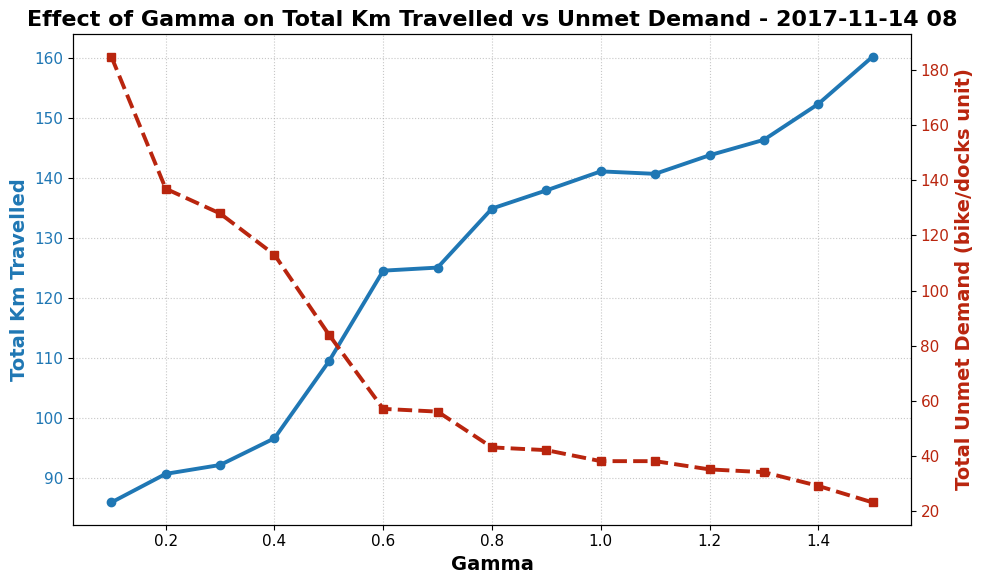

In [32]:
# Compute unmet demand as P + Q
metrics_df['total_unmet_demand'] = metrics_df['total_P'] + metrics_df['total_Q']

plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "axes.titleweight": "bold",
    "axes.labelweight": "bold",
    "legend.fontsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "lines.linewidth": 2.8
})

fig, ax1 = plt.subplots(figsize=(10,6))

# Colors
color_km = "#1f77b4"
color_unmet = "#b9250e"

# Left axis: total km travelled
line1 = ax1.plot(
    metrics_df['gamma'],
    metrics_df['total_km_travelled'],
    marker='o',
    color=color_km,
    linestyle='-'
)
ax1.set_xlabel("Gamma", fontweight="bold")
ax1.set_ylabel("Total Km Travelled", fontweight="bold", color=color_km)
ax1.tick_params(axis='y', labelcolor=color_km)
ax1.grid(True, linestyle=":", alpha=0.7)

# Right axis: total unmet demand (P+Q)
ax2 = ax1.twinx()
line2 = ax2.plot(
    metrics_df['gamma'],
    metrics_df['total_unmet_demand'],
    marker='s',
    color=color_unmet,
    linestyle='--'
)
ax2.set_ylabel("Total Unmet Demand (bike/docks unit)", fontweight="bold", color=color_unmet)
ax2.tick_params(axis='y', labelcolor=color_unmet)

# Title
ax1.set_title(f"Effect of Gamma on Total Km Travelled vs Unmet Demand - {hour_to_optimize[:-6]}", fontweight="bold")

plt.tight_layout()
plt.show()